# 04 — Kaplan-Meier Survival Curves

**Goal:** Visualise *when* borrowers default, not just *if* they default.
Kaplan-Meier curves stratified by **Traffic Light risk band** demonstrate
that the model correctly orders borrowers by time-to-default risk.

## Contents
1. Load application data & derive loan duration
2. Assign Traffic Light bands using trained model
3. Fit KM curves per risk band
4. Plot survival curves
5. Log-rank test (statistical significance)
6. Segment analysis: KM by employment / income type
7. Segment analysis: KM by occupation type  ← NEW
8. Segment analysis: KM by age band  ← NEW
9. Default-rate comparison table across segments  ← NEW
10. Key insight: median months to default by band

In [1]:
import sys, warnings, os
from pathlib import Path

_root = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path().resolve().parent
sys.path.insert(0, str(_root / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models import DefaultClassifier, KaplanMeierAnalyser, derive_loan_duration
from utils.config import load_config  # side-effect: os.chdir(project_root)

sns.set_theme(style='whitegrid')
cfg = load_config()

# Load trained model
clf = DefaultClassifier.load('outputs/models', cfg)
print('Model loaded. CWD:', os.getcwd())


2026-04-08 00:12:34 | INFO     | models.xgboost_classifier | Model loaded from outputs\models
Model loaded. CWD: C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\proactive-defaulter-flagging-system


## 1. Load Data & Derive Loan Duration

In [2]:
df = pd.read_csv('data/processed/feature_cache/master_features.csv')
df = derive_loan_duration(df)

print(f'Data shape: {df.shape}')
print(f'loan_months stats:\n{df["loan_months"].describe()}')


Data shape: (50000, 186)
loan_months stats:
count    49999.000000
mean        21.642400
std          7.831805
min          8.036739
25%         15.649452
50%         20.000000
75%         27.224313
max         45.295526
Name: loan_months, dtype: float64


## 2. Assign Traffic Light Bands

In [3]:
X = df.reindex(columns=clf.feature_columns, fill_value=0)
bands = clf.predict_traffic_light(X)
df['risk_band']   = bands['risk_band'].values
df['risk_score']  = bands['risk_score'].values

print('Band distribution:')
print(df['risk_band'].value_counts())

Band distribution:
risk_band
GREEN     34392
YELLOW    10772
RED        4836
Name: count, dtype: int64


## 3 & 4. Kaplan-Meier Curves by Risk Band

2026-04-08 00:12:47 | INFO     | models.survival_model | Fitting Kaplan-Meier curves by 'risk_band' ...


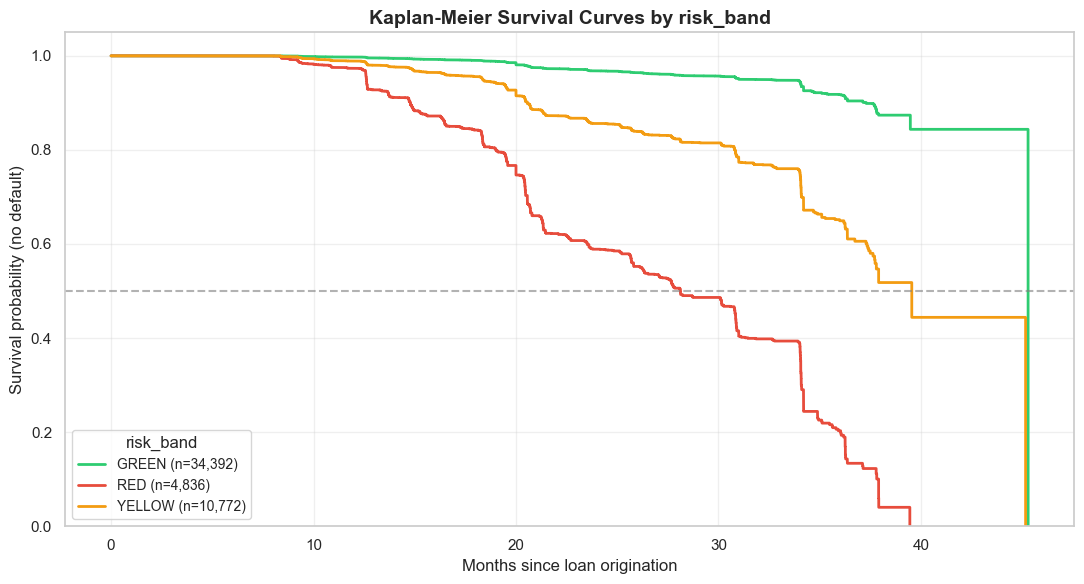

In [4]:
km = KaplanMeierAnalyser(df, duration_col='loan_months', event_col='TARGET')
km.fit_by_group('risk_band')

fig = km.plot(figsize=(11, 6))
os.makedirs('outputs/figures', exist_ok=True)
fig.savefig('outputs/figures/04_km_by_risk_band.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


## 5. Log-Rank Test (Statistical Significance)

In [5]:
pairs = [('RED','YELLOW'), ('RED','GREEN'), ('YELLOW','GREEN')]
print('Log-rank p-values (null: identical survival):')
for a, b in pairs:
    p = km.log_rank_pvalue(a, b)
    sig = '*** SIGNIFICANT' if p < 0.05 else 'NOT significant'
    print(f'  {a} vs {b}: p = {p:.4e}  →  {sig}')

Log-rank p-values (null: identical survival):
  RED vs YELLOW: p = 2.0698e-292  →  *** SIGNIFICANT
  RED vs GREEN: p = 0.0000e+00  →  *** SIGNIFICANT
  YELLOW vs GREEN: p = 0.0000e+00  →  *** SIGNIFICANT


## 6. Segment Analysis — KM by Employment Type

2026-04-08 00:12:58 | INFO     | models.survival_model | Fitting Kaplan-Meier curves by 'NAME_INCOME_TYPE' ...


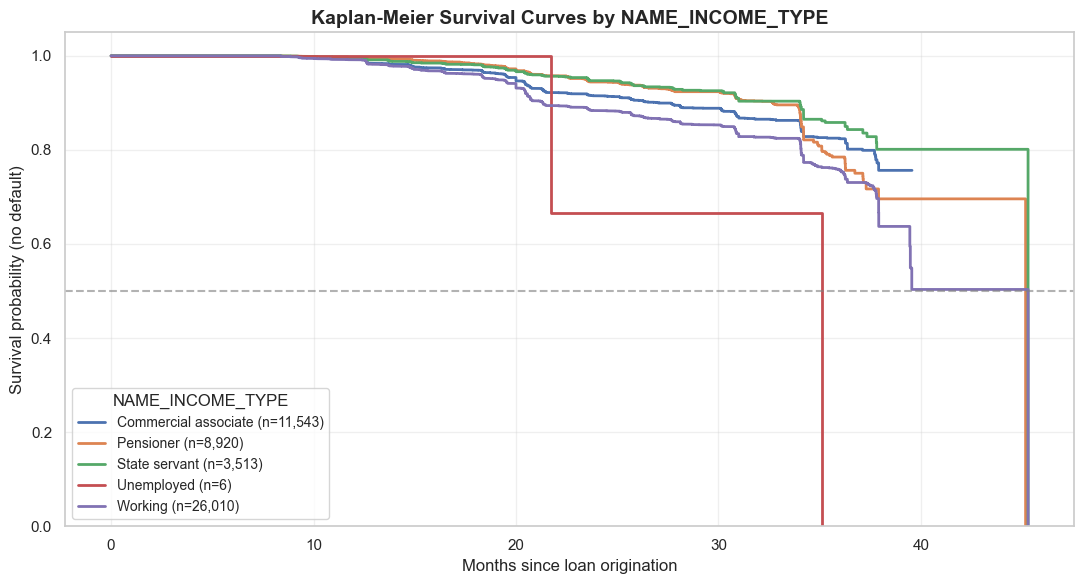

In [6]:
if 'NAME_INCOME_TYPE' in df.columns:
    top_income_types = df['NAME_INCOME_TYPE'].value_counts().head(5).index
    df_emp = df[df['NAME_INCOME_TYPE'].isin(top_income_types)].copy()

    km_emp = KaplanMeierAnalyser(df_emp, duration_col='loan_months', event_col='TARGET')
    km_emp.fit_by_group('NAME_INCOME_TYPE')
    fig2 = km_emp.plot(figsize=(11, 6))
    fig2.savefig('outputs/figures/04_km_by_employment.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
else:
    print('NAME_INCOME_TYPE not in master features — skipping segment analysis.')

## 7. Segment Analysis — KM by Occupation Type

EDA (NB01) showed that low-skill labourers default at ~17 % vs managers at ~3 %.
The KM curve below validates whether that difference manifests as *faster* default
time as well as higher overall default probability.

2026-04-08 00:13:04 | INFO     | models.survival_model | Fitting Kaplan-Meier curves by 'OCCUPATION_TYPE' ...


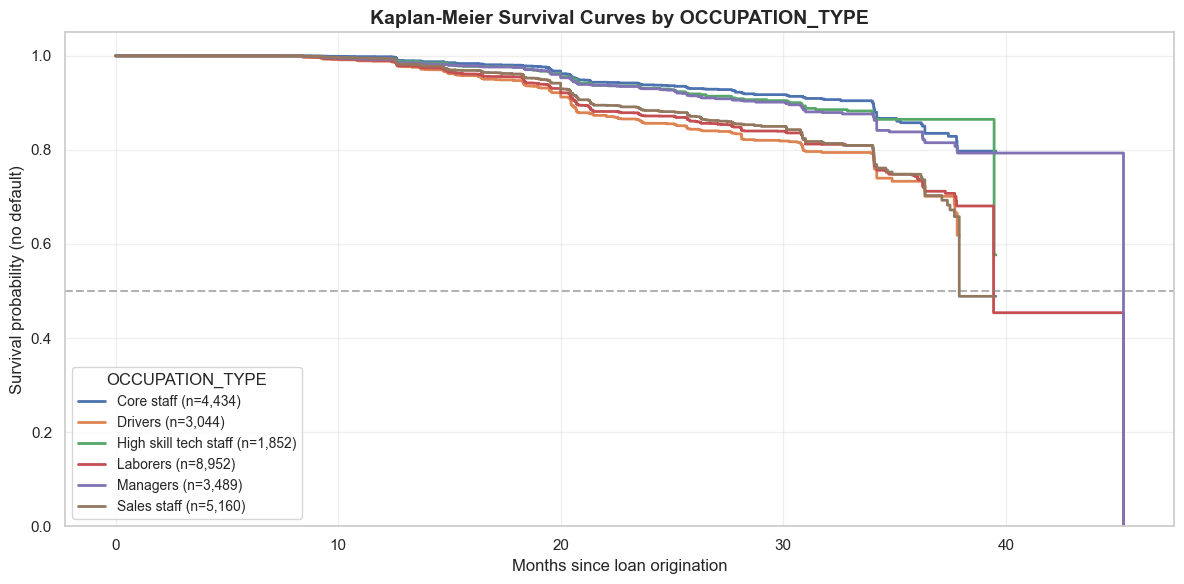


Observed default rates by occupation type:
                          n  defaults  default_rate
OCCUPATION_TYPE                                    
Drivers                3044       338      0.111038
Laborers               8952       920      0.102770
Sales staff            5160       492      0.095349
Managers               3489       243      0.069647
High skill tech staff  1852       118      0.063715
Core staff             4434       250      0.056382


In [7]:
if 'OCCUPATION_TYPE' in df.columns:
    top_occ = df['OCCUPATION_TYPE'].value_counts().head(6).index
    df_occ = df[df['OCCUPATION_TYPE'].isin(top_occ)].copy()

    km_occ = KaplanMeierAnalyser(df_occ, duration_col='loan_months', event_col='TARGET')
    km_occ.fit_by_group('OCCUPATION_TYPE')

    fig3 = km_occ.plot(figsize=(12, 6))
    os.makedirs('outputs/figures', exist_ok=True)
    fig3.savefig('outputs/figures/04_km_by_occupation.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig3)

    # Observed default rate per occupation (EDA confirmation)
    occ_dr = (
        df_occ.groupby('OCCUPATION_TYPE')['TARGET']
        .agg(n='count', defaults='sum')
        .assign(default_rate=lambda x: x['defaults'] / x['n'])
        .sort_values('default_rate', ascending=False)
    )
    print('\nObserved default rates by occupation type:')
    print(occ_dr.to_string())
else:
    print('OCCUPATION_TYPE not in master features — skipping occupation analysis.')

## 8. Segment Analysis — KM by Age Band

Younger applicants (<30) tend to have thinner credit histories and default more
frequently. Stratifying KM curves by age band confirms whether this translates
to systematically earlier defaults.

2026-04-08 00:13:14 | INFO     | models.survival_model | Fitting Kaplan-Meier curves by 'age_band' ...


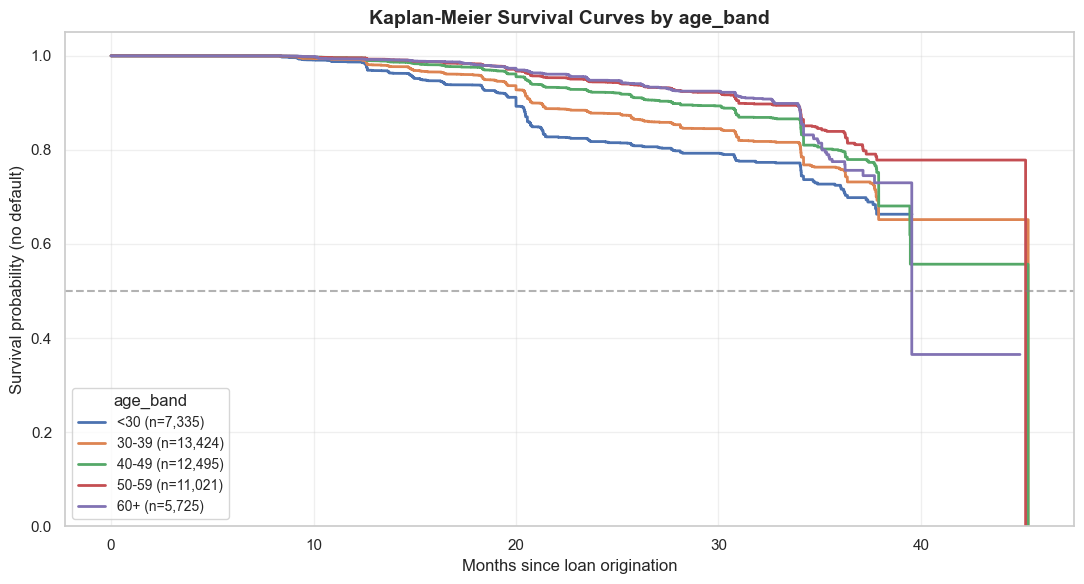


Observed default rates by age band (confirms EDA monotonic trend):
              n  defaults  default_rate
age_band                               
<30        7335       822      0.112065
30-39     13424      1313      0.097810
40-49     12495       937      0.074990
50-59     11021       666      0.060430
60+        5725       288      0.050306


In [8]:
age_col = 'age_years' if 'age_years' in df.columns else (
    'DAYS_BIRTH' if 'DAYS_BIRTH' in df.columns else None
)

if age_col:
    if age_col == 'DAYS_BIRTH':
        df['age_years'] = np.abs(df['DAYS_BIRTH']) / 365.25
    df['age_band'] = pd.cut(
        df['age_years'],
        bins=[0, 30, 40, 50, 60, 120],
        labels=['<30', '30-39', '40-49', '50-59', '60+']
    )
    df_age = df.dropna(subset=['age_band']).copy()

    km_age = KaplanMeierAnalyser(df_age, duration_col='loan_months', event_col='TARGET')
    km_age.fit_by_group('age_band')

    fig4 = km_age.plot(figsize=(11, 6))
    fig4.savefig('outputs/figures/04_km_by_age_band.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig4)

    age_dr = (
        df_age.groupby('age_band', observed=True)['TARGET']
        .agg(n='count', defaults='sum')
        .assign(default_rate=lambda x: x['defaults'] / x['n'])
    )
    print('\nObserved default rates by age band (confirms EDA monotonic trend):')
    print(age_dr.to_string())
else:
    print('No age column found in master features — skipping age band analysis.')

## 9. Default-Rate Comparison Table Across Segments

A single table summarising default rates across Traffic Light bands, income type,
occupation type and age band — useful for executive reporting.

In [9]:
def _seg_table(df_, col, label_col):
    """Compute default rate per category for a given column."""
    if col not in df_.columns:
        return pd.DataFrame()
    tbl = (
        df_.groupby(col)['TARGET']
        .agg(n='count', defaults='sum')
        .assign(default_rate=lambda x: x['defaults'] / x['n'],
                segment_type=label_col)
        .reset_index()
        .rename(columns={col: 'segment_value'})
    )
    return tbl[['segment_type', 'segment_value', 'n', 'default_rate']]

rows = []
rows.append(_seg_table(df, 'risk_band', 'Traffic Light Band'))
if 'NAME_INCOME_TYPE' in df.columns:
    rows.append(_seg_table(df, 'NAME_INCOME_TYPE', 'Income Type'))
if 'OCCUPATION_TYPE' in df.columns:
    rows.append(_seg_table(df, 'OCCUPATION_TYPE', 'Occupation Type'))
if 'age_band' in df.columns:
    rows.append(_seg_table(df, 'age_band', 'Age Band'))

summary_tbl = pd.concat([r for r in rows if not r.empty], ignore_index=True)
summary_tbl['default_rate_pct'] = (summary_tbl['default_rate'] * 100).round(2)

print('=== Default Rate Comparison Table ===')
print(summary_tbl.sort_values(['segment_type', 'default_rate'], ascending=[True, False])
      .to_string(index=False))

# Save as CSV for reporting
os.makedirs('outputs/reports', exist_ok=True)
summary_tbl.to_csv('outputs/reports/segment_default_rates.csv', index=False)
print('\nSaved → outputs/reports/segment_default_rates.csv')

=== Default Rate Comparison Table ===
      segment_type         segment_value     n  default_rate  default_rate_pct
          Age Band                   <30  7335      0.112065             11.21
          Age Band                 30-39 13424      0.097810              9.78
          Age Band                 40-49 12495      0.074990              7.50
          Age Band                 50-59 11021      0.060430              6.04
          Age Band                   60+  5725      0.050306              5.03
       Income Type            Unemployed     6      0.333333             33.33
       Income Type               Working 26010      0.094617              9.46
       Income Type  Commercial associate 11543      0.074851              7.49
       Income Type         State servant  3513      0.056362              5.64
       Income Type             Pensioner  8920      0.056166              5.62
       Income Type           Businessman     2      0.000000              0.00
       Income 

## 10. Key Insight — Median Months to Default by Risk Band

The median survival time (months until 50 % of the group has defaulted) directly
quantifies *how much earlier* RED-band borrowers default relative to GREEN-band.
This is the core operational insight that drives intervention urgency.

In [10]:
median_df = km.median_survival()
median_df = median_df.rename(columns={'group': 'risk_band'})
print('Median months until default by risk band:')
print(median_df.to_string(index=False))

# ----- interpretive summary -----
print()
print('=' * 55)
print('  KEY INSIGHTS')
print('=' * 55)

band_dr = df.groupby('risk_band')['TARGET'].mean().round(4) * 100
for band in ['RED', 'YELLOW', 'GREEN']:
    med = median_df[median_df['risk_band'] == band]['median_survival_months']
    med_str = f'{med.values[0]:.0f} months' if not med.empty and not pd.isna(med.values[0]) else 'not reached'
    dr_str  = f'{band_dr.get(band, float("nan")):.1f}%'
    print(f'  {band:6s}  default rate={dr_str:<7}  median survival={med_str}')

print()
print('  Interpretation:')
print('  · RED-band borrowers default both more *frequently* AND *sooner*.')
print('  · The gap between GREEN and RED median survival translates directly')
print('    into the proactive intervention window available to the lender.')
print('  · Earlier flagging → earlier outreach → higher cure rate.')

Median months until default by risk band:
risk_band  median_survival_months
    GREEN               45.291270
      RED               28.117380
   YELLOW               39.548023

  KEY INSIGHTS
  RED     default rate=35.5%    median survival=28 months
  YELLOW  default rate=12.2%    median survival=40 months
  GREEN   default rate=2.9%     median survival=45 months

  Interpretation:
  · RED-band borrowers default both more *frequently* AND *sooner*.
  · The gap between GREEN and RED median survival translates directly
    into the proactive intervention window available to the lender.
  · Earlier flagging → earlier outreach → higher cure rate.
